<a href="https://colab.research.google.com/github/ArshiaSingh05/Platform-Identification-System-using-Acoustic-Signature/blob/main/DRDO_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pandas

In [3]:
!pip install matplotlib seaborn glob2 ipython librosa numpy scipy soxr
# Before installing librosa we have to install other dependencies also because it has many dependencies in itself.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.9 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

from glob2 import glob
import librosa
import librosa.display
import IPython.display as ipd

from itertools import cycle

sns.set_theme(style="white", palette=None)
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_cycle = cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"])

In [5]:
# from glob import glob

# Load all .wav files from dolphin, torpedo, and ship folders
# audio_files = glob("/content/audio_files.zip")
# print(audio_files)
#from google.colab import files
#uploaded = files.upload()
#import zipfile
#with zipfile.ZipFile("/content/audio_files.zip", 'r') as zip_ref:
 #   zip_ref.extractall("/content/audio_files")
#from glob import glob

#audio_files = glob("/content/audio_files/**/*/*.wav", recursive=True)
#print(f"Total audio files: {len(audio_files)}")
#print(audio_files[:5])  # see first 5 paths

In [6]:
# LABEL = SHIP TYPE

# print(len(audio_files))

In [8]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [9]:
from IPython.display import Audio as ipdAudio
from glob import glob
path = "/content/drive/MyDrive/audio_files"
audio_files = glob(path + "/**/*.wav", recursive=True)
print(f"Total audio files found: {len(audio_files)}")
print(audio_files[:5])
ipdAudio(audio_files[50])


Total audio files found: 276
['/content/drive/MyDrive/audio_files/dolphins/Tursiops_dolphin001.wav', '/content/drive/MyDrive/audio_files/dolphins/Tursiops_dolphin002.wav', '/content/drive/MyDrive/audio_files/dolphins/Tursiops_dolphin003.wav', '/content/drive/MyDrive/audio_files/dolphins/Tursiops_dolphin004.wav', '/content/drive/MyDrive/audio_files/dolphins/Tursiops_dolphin005.wav']


In [10]:
!pip install librosa

In [11]:
!pip show librosa

Name: librosa
Version: 0.11.0
Summary: Python module for audio and music processing
Home-page: https://librosa.org
Author: Brian McFee, librosa development team
Author-email: brian.mcfee@nyu.edu
License: ISC
Location: /usr/local/lib/python3.11/dist-packages
Requires: audioread, decorator, joblib, lazy_loader, msgpack, numba, numpy, pooch, scikit-learn, scipy, soundfile, soxr, typing_extensions
Required-by: 


In [12]:
import librosa

In [13]:
#pip install --upgrade paramiko cryptography


In [14]:
pip install cryptography==42.0.8


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 18.3 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3


In [15]:
!pip show cryptography
!pip show pyopenssl



Name: cryptography
Version: 42.0.8
Summary: cryptography is a package which provides cryptographic recipes and primitives to Python developers.
Home-page: https://github.com/pyca/cryptography
Author: 
Author-email: The Python Cryptographic Authority and individual contributors <cryptography-dev@python.org>
License: Apache-2.0 OR BSD-3-Clause
Location: /usr/local/lib/python3.11/dist-packages
Requires: cffi
Required-by: PyDrive2, pyOpenSSL, SecretStorage
Name: pyOpenSSL
Version: 24.2.1
Summary: Python wrapper module around the OpenSSL library
Home-page: https://pyopenssl.org/
Author: The pyOpenSSL developers
Author-email: cryptography-dev@python.org
License: Apache License, Version 2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: cryptography
Required-by: PyDrive2


In [16]:
y, sr = librosa.load(audio_files[48])
# y -> raw data of the audio file
# sr -> sampling rate of the audio file

In [17]:
print(f'y: {y[:10]}')
print(f'y shape: {y.shape}')
print(f'sr: {sr}')

y: [0.00090283 0.00185514 0.00118789 0.0016127  0.00037635 0.0027916
 0.00067977 0.00110399 0.00191858 0.00064474]
y shape: (31997,)
sr: 22050


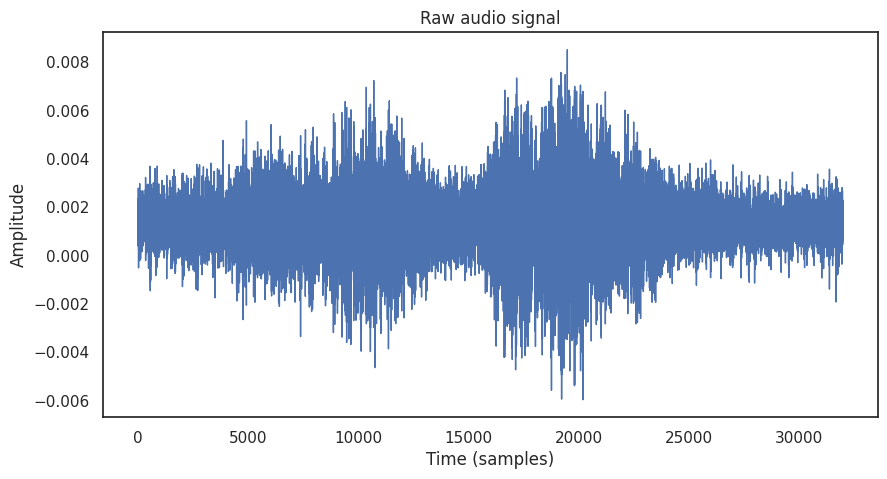

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_theme(style="white")
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]
pd.Series(y).plot(figsize=(10, 5),lw = 1,color = color_pal[0])
plt.title('Raw audio signal')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.show()

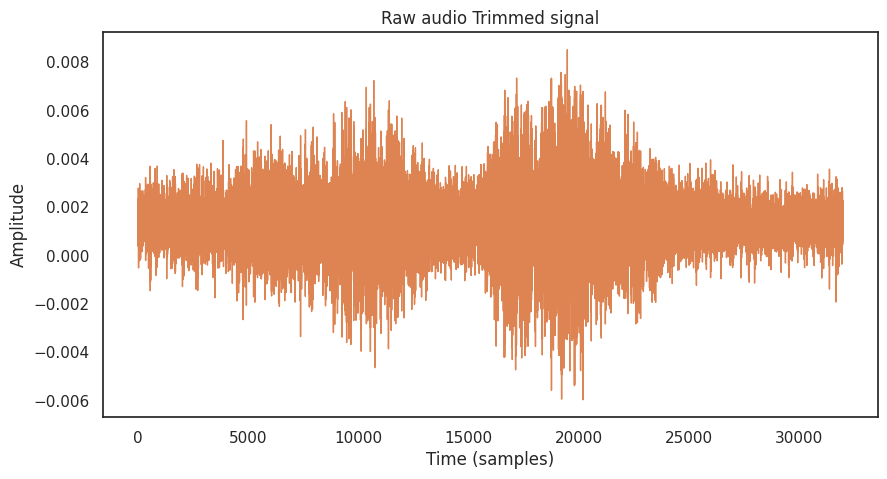

In [19]:
y_trimmed, _ = librosa.effects.trim(y,top_db=20)
#  help to trim(remove) empty spaces...plane lines
pd.Series(y).plot(figsize=(10, 5),lw = 1,color = color_pal[1])
plt.title('Raw audio Trimmed signal')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.show()

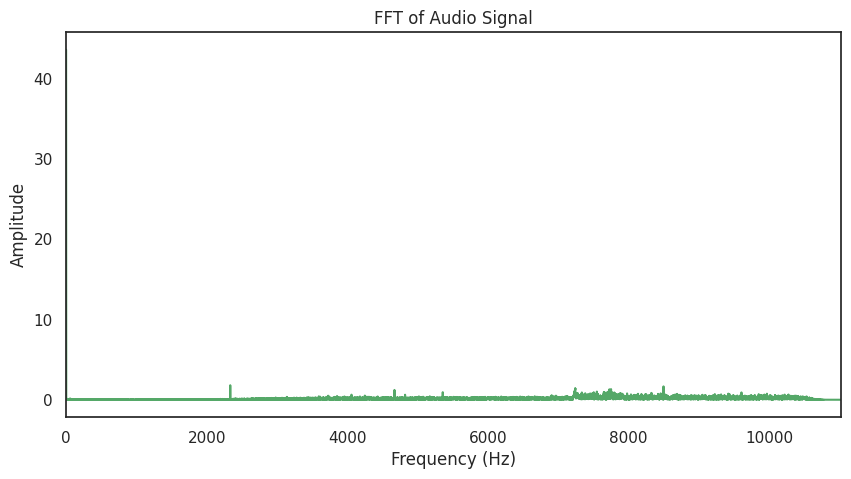

In [20]:
# Compute the Fast Fourier Transform (FFT) of the audio signal
# This will convert the time-domain signal into the frequency domain.
# The FFT is a powerful algorithm to compute the Discrete Fourier Transform (DFT) and its inverse.
fft_vals = np.fft.fft(y)
fft_freq = np.fft.fftfreq(len(fft_vals), 1/sr)

# Only take the positive frequencies
pos_mask = fft_freq >= 0
fft_freq = fft_freq[pos_mask]
fft_power = np.abs(fft_vals[pos_mask])

plt.figure(figsize=(10, 5))
plt.plot(fft_freq, fft_power, color=color_pal[2])
plt.title('FFT of Audio Signal')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim([0, sr/2])
plt.show()

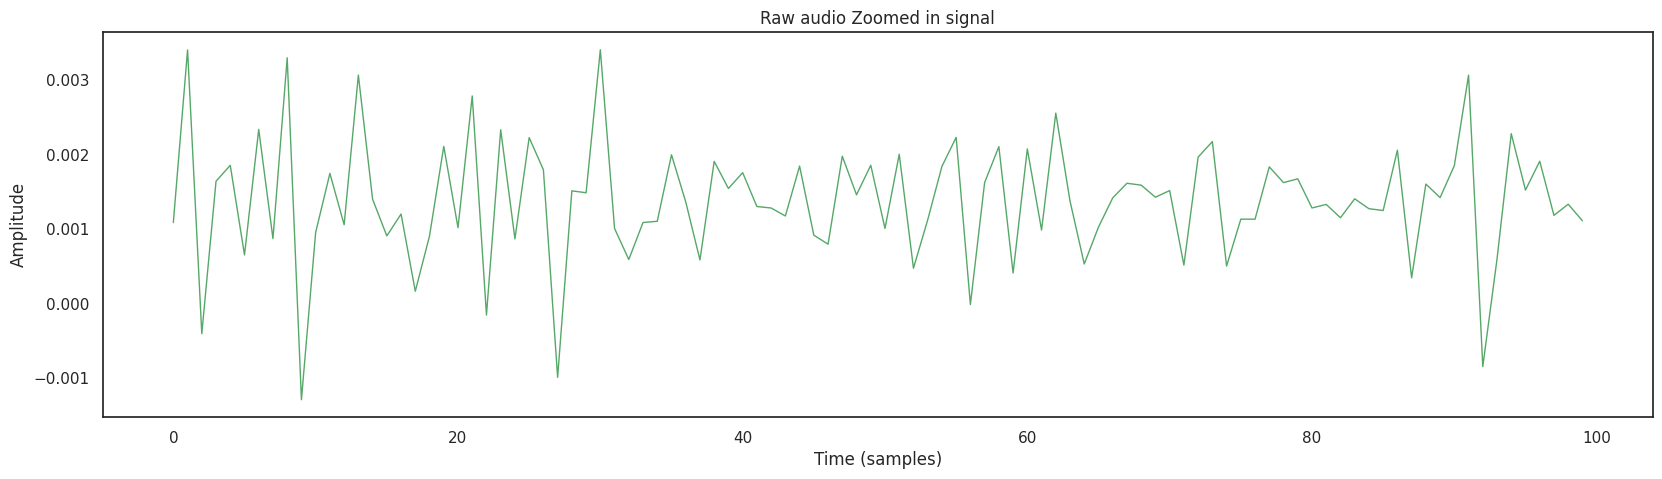

In [21]:
pd.Series(y[2000:2100]).plot(figsize=(20, 5),lw = 1,color = color_pal[2])
plt.title('Raw audio Zoomed in signal')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.show()


In [22]:
# Calculate average power (mean of squared amplitude)
avg_power = np.mean(fft_power ** 2)

# Intensity is often proportional to power for audio signals
avg_intensity = avg_power

# Sample rate is already given by sr
avg_sample_rate = sr

# Loudness can be estimated as the mean dB value of the FFT power (avoid log(0) by adding small epsilon)
epsilon = 1e-10
loudness_db = 10 * np.log10(fft_power + epsilon)
avg_loudness = np.mean(loudness_db)

print(f"Average Power: {avg_power}")
print(f"Average Intensity: {avg_intensity}")
print(f"Sample Rate: {avg_sample_rate}")
print(f"Average Loudness (dB): {avg_loudness}")

Average Power: 0.16256500780582428
Average Intensity: 0.16256500780582428
Sample Rate: 22050
Average Loudness (dB): -10.938450813293457


In [23]:
# Compute the Short-Time Fourier Transform (STFT)
# This will give us a time-frequency representation of the audio signal
trans = librosa.stft(y)
spect_db = librosa.amplitude_to_db(np.abs(trans), ref=np.max)
spect_db.shape

(1025, 63)

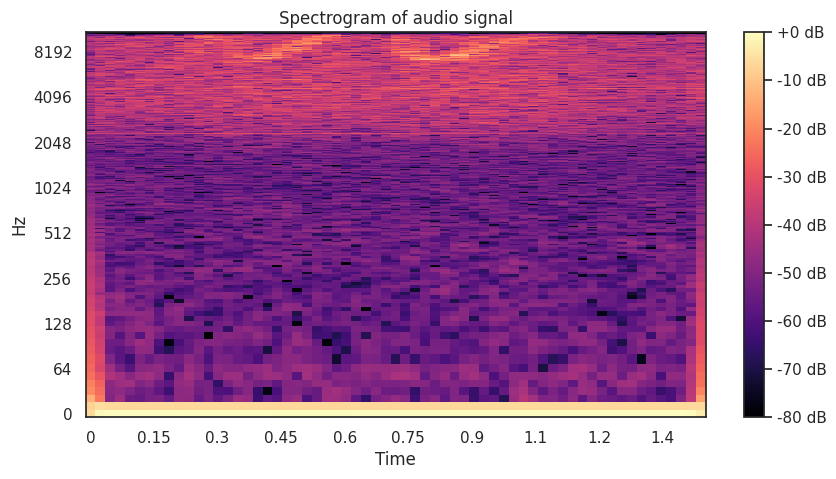

In [24]:
# Plot the transformed audio data
fig , ax = plt.subplots(figsize=(10, 5))
img = librosa.display.specshow(spect_db,x_axis='time', y_axis='log', ax=ax)
ax.set_title('Spectrogram of audio signal')
fig.colorbar(img, ax=ax, format="%+2.f dB")

Mel Spectrogram

In [25]:
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_dB = librosa.amplitude_to_db(S, ref=np.max)

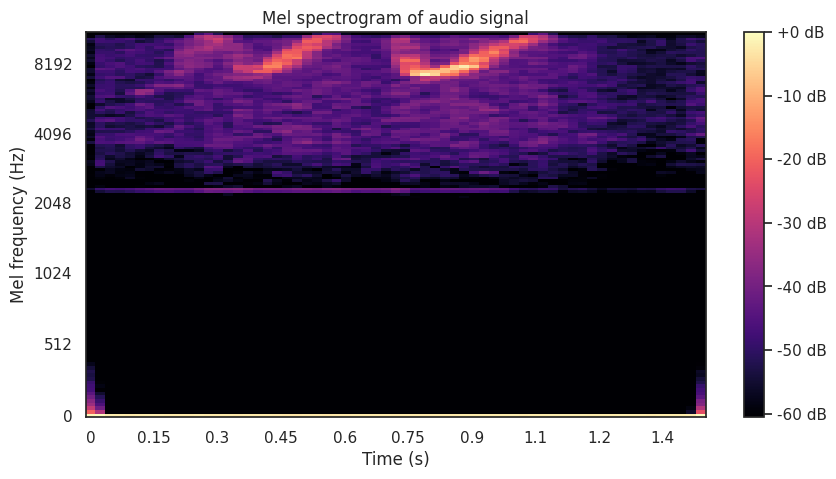

In [26]:
fig,ax =  plt.subplots(figsize=(10, 5))
plt.title('Mel spectrogram of audio signal')
# plot the mel spectrogram

img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr)
plt.colorbar(img, format="%+2.f dB")
plt.xlabel('Time (s)')
plt.ylabel('Mel frequency (Hz)')
plt.show()

--Data Preprocessing--

In [27]:
import os
import numpy as np
from glob import glob
import librosa
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder


Step-1: Getting File Paths and Labels

In [28]:
# Path to your dataset
base_path = "/content/drive/MyDrive/audio_files"

# Get all .wav files from all subfolders
audio_files = glob(base_path + "/*/*.wav")

# Extract labels (folder names like dolphin, torpedo, ship)
labels = [file.split("/")[-2] for file in audio_files]

# Encode string labels to integers
le = LabelEncoder()
encoded_labels = le.fit_transform(labels)

print("Classes:", le.classes_)  # Output: ['dolphin' 'ship' 'torpedo']


Classes: ['Submarine' 'Torpedo' 'dolphins']


Step-2: Define a Function to Extract Features (e.g., MFCC)

In [29]:
def extract_features(file_path, max_pad_len=862):  # 862 = around 5 sec for 22050Hz
    try:
        audio, sample_rate = librosa.load(file_path, sr=22050)
        mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)

        # Padding or trimming to fixed length
        if mfcc.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :max_pad_len]

        return mfcc
    except Exception as e:
        print("Error processing", file_path, ":", e)
        return None

Step-3: Apply Feature Extraction on All Files

In [30]:
features = []
final_labels = []

for i, file_path in enumerate(audio_files):
    mfcc = extract_features(file_path)
    if mfcc is not None:
        features.append(mfcc)
        final_labels.append(encoded_labels[i])


Step-4: Convert to NumPy Arrays for Model Input

In [31]:
X = np.array(features)                     # Shape: (num_samples, 40, 862)
X = X[..., np.newaxis]                    # Add channel dimension for CNN: (samples, 40, 862, 1)
y = np.array(final_labels)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (276, 40, 862, 1)
y shape: (276,)


**Marine Acoustic Signature Classification using CRNN**

In [32]:
!pip install tensorflow


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.regularizers import l2

In [46]:
num_classes = len(np.unique(y_train))
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat  = to_categorical(y_test,  num_classes=num_classes)

class_names = [f"class_{i}" for i in range(num_classes)]

from tensorflow.keras.layers import Input, LSTM, Reshape, Bidirectional

In [47]:
model = Sequential([
    Input(shape=(40, 862, 1)),

    # CNN Layers with L2 regularization and BatchNormalization
    Conv2D(32, kernel_size=(3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.4),  # ✅ Increased dropout

    Conv2D(64, kernel_size=(3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.4),  # ✅ Increased dropout

    # Reshape for RNN
    Reshape((8, 214 * 64)),

    # RNN Layer
    Bidirectional(LSTM(64, return_sequences=False)),

    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.4),  # ✅ Increased dropout

    Dense(num_classes, activation='softmax')
])

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 38, 860, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 38, 860, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 19, 430, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 19, 430, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 17, 428, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 428, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 214, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 214, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 8, 13696)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │     7,045,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,073,283 (26.98 MB)

 Trainable params: 7,073,091 (26.98 MB)

 Non-trainable params: 192 (768.00 B)

In [48]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_cnn.h5", save_best_only=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

In [49]:
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=20,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7217 - loss: 0.8203
Epoch 1: val_loss improved from inf to 0.90576, saving model to best_cnn.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.7286 - loss: 0.8024 - val_accuracy: 0.5357 - val_loss: 0.9058 - learning_rate: 0.0010
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8572 - loss: 0.5202
Epoch 2: val_loss improved from 0.90576 to 0.89512, saving model to best_cnn.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 47s 5s/step - accuracy: 0.8586 - loss: 0.5159 - val_accuracy: 0.6071 - val_loss: 0.8951 - learning_rate: 0.0010
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8874 - loss: 0.4712
Epoch 3: val_loss improved from 0.89512 to 0.78385, saving model to best_cnn.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step - accuracy: 0.8884 - loss: 0.4701 - val_accuracy: 0.7321 - val_loss: 0.7839 - learning_rate: 0.0010
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8870 - loss: 0.4389
Epoch 4: val_loss improved from 0.78385 to 0.75532, saving model to best_cnn.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.8858 - loss: 0.4396 - val_accuracy: 0.7500 - val_loss: 0.7553 - learning_rate: 0.0010
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8887 - loss: 0.4525
Epoch 5: val_loss improved from 0.75532 to 0.68083, saving model to best_cnn.h5


...

7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9368 - loss: 0.2806 - val_accuracy: 0.8929 - val_loss: 0.4356 - learning_rate: 0.0010
Epoch 15/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9429 - loss: 0.2662
Epoch 15: val_loss did not improve from 0.43555
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9426 - loss: 0.2671 - val_accuracy: 0.8750 - val_loss: 0.4435 - learning_rate: 0.0010
Epoch 16/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9488 - loss: 0.2588
Epoch 16: val_loss improved from 0.43555 to 0.43398, saving model to best_cnn.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 43s 4s/step - accuracy: 0.9484 - loss: 0.2591 - val_accuracy: 0.9107 - val_loss: 0.4340 - learning_rate: 0.0010
Epoch 17/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9572 - loss: 0.2737
Epoch 17: val_loss did not improve from 0.43398
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9574 - loss: 0.2706 - val_accuracy: 0.8750 - val_loss: 0.4378 - learning_rate: 0.0010
Epoch 18/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9717 - loss: 0.2154
Epoch 18: val_loss improved from 0.43398 to 0.42619, saving model to best_cnn.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9718 - loss: 0.2151 - val_accuracy: 0.8750 - val_loss: 0.4262 - learning_rate: 0.0010
Epoch 19/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9610 - loss: 0.2231
Epoch 19: val_loss improved from 0.42619 to 0.41739, saving model to best_cnn.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - accuracy: 0.9613 - loss: 0.2230 - val_accuracy: 0.8929 - val_loss: 0.4174 - learning_rate: 0.0010
Epoch 20/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9812 - loss: 0.2110
Epoch 20: val_loss improved from 0.41739 to 0.41492, saving model to best_cnn.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 36s 4s/step - accuracy: 0.9795 - loss: 0.2124 - val_accuracy: 0.8750 - val_loss: 0.4149 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 20.


In [50]:
# Evaluation
y_pred_prob = model.predict(X_test)
y_pred      = y_pred_prob.argmax(axis=1)
y_true      = y_test_cat.argmax(axis=1)

print("\nClassification report\n")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\nConfusion matrix\n")
print(confusion_matrix(y_true, y_pred))

# Save model
model.save("cnn_full_pipeline.keras")

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 775ms/step

Classification report

              precision    recall  f1-score   support

     class_0       0.73      0.67      0.70        12
     class_1       1.00      0.80      0.89         5
     class_2       0.90      0.95      0.93        39

    accuracy                           0.88        56
   macro avg       0.88      0.81      0.84        56
weighted avg       0.87      0.88      0.87        56


Confusion matrix

[[ 8  0  4]
 [ 1  4  0]
 [ 2  0 37]]


In [51]:
file_path = '/content/drive/MyDrive/testing_audios/testing_audio003.wav'

# Extract features like before
test_mfcc = extract_features(file_path)
test_mfcc = test_mfcc[np.newaxis, ..., np.newaxis]  # shape (1, 40, 862, 1)

# Make prediction
pred = model.predict(test_mfcc)
pred_class = np.argmax(pred)

# Decode class label
pred_label = le.inverse_transform([pred_class])[0]

# Print result with confidence
confidence = pred[0][pred_class] * 100
print(f"I am {confidence:.2f}% sure this is the sound of a '{pred_label}'.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
I am 98.12% sure this is the sound of a 'dolphins'.


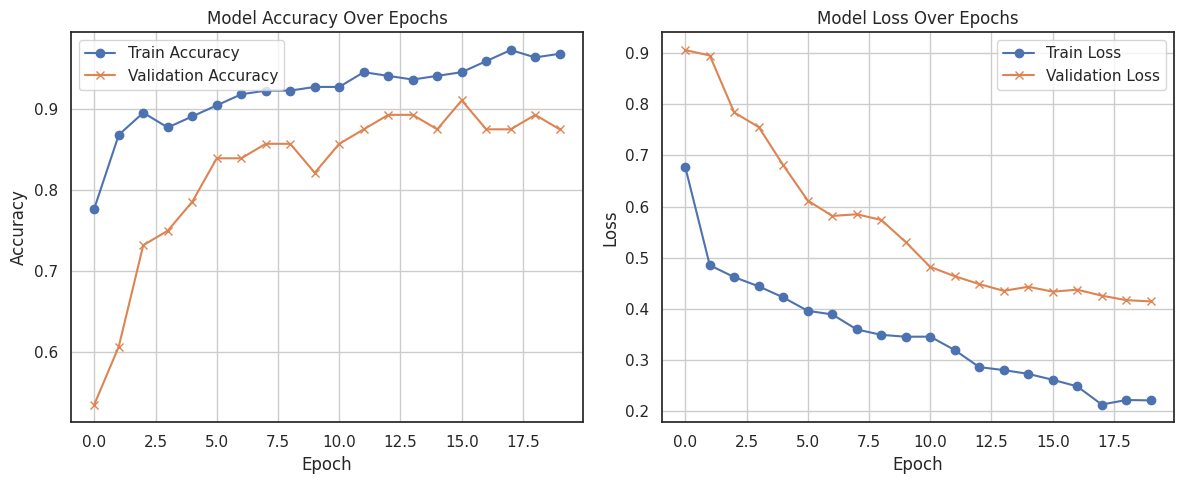

In [54]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
